In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv('IBM.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


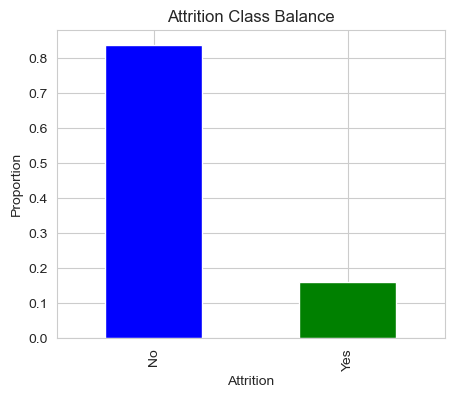

In [12]:
df['Attrition'].value_counts(normalize=True).plot(
    kind='bar' , color=['blue', 'green'] , figsize = (5,4) , title='Attrition Class Balance'
)
plt.ylabel('Proportion')
plt.show()

In [ ]:
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df=df.drop(columns=drop_cols)


KeyError: "['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'] not found in axis"

In [15]:
df.shape

(1470, 31)

In [19]:
#encode 

target = df['Attrition'].map({'Yes' : 1 , 'No' : 0})
X = df.drop(columns=['Attrition'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col]=le.fit_transform(X[col])
    encoders[col]= le

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.2, stratify=target, random_state=42
)

In [21]:
sm = SMOTE(random_state=42)
X_train_res , y_train_res = sm.fit_resample(X_train , y_train)
print("Resampled class balance:", y_train_res.mean().round(3))

Resampled class balance: 0.5


In [22]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [23]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       247
           1       0.36      0.32      0.34        47

    accuracy                           0.80       294
   macro avg       0.62      0.60      0.61       294
weighted avg       0.79      0.80      0.79       294

ROC-AUC: 0.7398


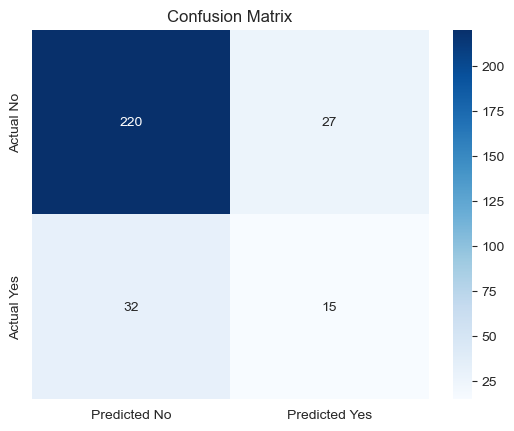

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No', 'Predicted Yes'],
            yticklabels=['Actual No', 'Actual Yes'])
plt.title('Confusion Matrix')
plt.show()

In [25]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

fi_df = importances.reset_index()
fi_df.columns = ['Feature', 'Importance']
fi_df['Rank'] = fi_df.index + 1
fi_df['Importance_Pct'] = (fi_df['Importance'] / fi_df['Importance'].sum() * 100).round(2)
fi_df = fi_df[['Rank', 'Feature', 'Importance', 'Importance_Pct']]

fi_df.head(15)

,Rank,Feature,Importance,Importance_Pct
0,1,StockOptionLevel,0.098393,9.84
1,2,JobSatisfaction,0.062296,6.23
2,3,MonthlyIncome,0.059905,5.99
3,4,EnvironmentSatisfaction,0.050825,5.08
4,5,JobInvolvement,0.046296,4.63
5,6,YearsWithCurrManager,0.046243,4.62
6,7,Age,0.045028,4.50
7,8,MonthlyRate,0.042613,4.26
8,9,JobLevel,0.040179,4.02
9,10,TotalWorkingYears,0.039415,3.94


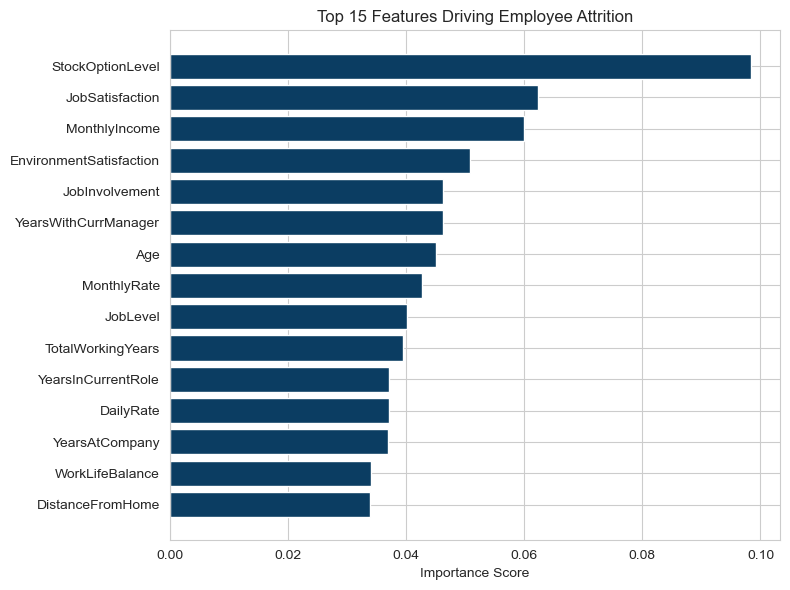

In [26]:
top15 = fi_df.head(15).sort_values('Importance')

plt.figure(figsize=(8,6))
plt.barh(top15['Feature'], top15['Importance'], color='#0B3D62')
plt.xlabel('Importance Score')
plt.title('Top 15 Features Driving Employee Attrition')
plt.tight_layout()
plt.savefig('feature_importance_chart.png', dpi=150)
plt.show()